## Sample code to run the FL models locally

In [ ]:
import torch.nn as nn
import numpy as np
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset

from shared import SimpleNet, eval_local, train_local, get_initial_arrays

In [ ]:
site_prefix = "OBI" # "MGL" #OBI #UOT # BHDC

synth_ds_dir = Path("../../../fed_learning/neuroFL/synthetic_ds") # ../../PD-challenge-ds-store/synthetic_ds/ 
features_subdir = synth_ds_dir / site_prefix / 'features'
labels_subdir = synth_ds_dir  / site_prefix / 'labels'

idp_subdir = features_subdir / 'idp'
mri_subdir = features_subdir / 'bids'
tabular_subdir = features_subdir / 'tabular'

demo_save_file = Path(f"{features_subdir}/tabular/demographics.tsv")
labels_save_file = Path(f"{labels_subdir}/labels.tsv")
idp_save_file = Path(f"{features_subdir}/idp/freesurfer-7.3.2.tsv")

In [ ]:
# initialize
input_dim = 134
new_arrays = get_initial_arrays(input_dim, dropout=0.0)

# start the training loop
train_performance = []
eval_performance = []
n_rounds = 5
n_epochs = 50

train_config = {
    "data-path": synth_ds_dir / site_prefix,
    "batch-size": 32,
    "epochs": n_epochs,
    "lr": 1e-2,
    "dropout": 0.0
}

test_config = {
    "data-path": synth_ds_dir / site_prefix,
    "batch-size": 1,
    "dropout": 0.0  
}

for round in range(n_rounds):
    print(f"Round {round+1}")
    new_arrays, num_examples, train_metrics = train_local(new_arrays, train_config)
    train_performance.append(train_metrics)

    avg_loss, total, eval_metrics = eval_local(new_arrays, test_config)

    print(f"Evaluation Metrics: {train_metrics}, {eval_metrics}")
    eval_performance.append(eval_metrics)

Round 1
Whole dataset mean: [2.08 2.1  1.97 2.03 2.04 1.99 1.51 1.47 2.89 2.88]
Whole dataset std: [0.39 0.38 0.39 0.39 0.38 0.37 0.28 0.26 0.57 0.53]
Before normalization:
Train mean: [2.06 2.07 1.98 2.01 2.04 1.96 1.51 1.48 2.87 2.89]
Train std: [0.39 0.39 0.39 0.39 0.39 0.38 0.29 0.24 0.58 0.54]
Validation mean: [2.17 2.19 1.94 2.11 2.05 2.1  1.51 1.42 2.94 2.84]
Validation std: [0.41 0.36 0.42 0.37 0.37 0.31 0.26 0.33 0.52 0.51]
After normalization:
Train mean: [ 0. -0. -0.  0. -0. -0.  0.  0.  0.  0.]
Train std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Validation mean: [ 0.27  0.29 -0.1   0.27  0.03  0.37  0.   -0.25  0.12 -0.11]
Validation std: [1.05 0.94 1.08 0.97 0.97 0.81 0.91 1.4  0.89 0.94]
Whole dataset mean: [2.08 2.1  1.97 2.03 2.04 1.99 1.51 1.47 2.89 2.88]
Whole dataset std: [0.39 0.38 0.39 0.39 0.38 0.37 0.28 0.26 0.57 0.53]
Before normalization:
Train mean: [2.06 2.07 1.98 2.01 2.04 1.96 1.51 1.48 2.87 2.89]
Train std: [0.39 0.39 0.39 0.39 0.39 0.38 0.29 0.24 0.58 0.54]
Valida

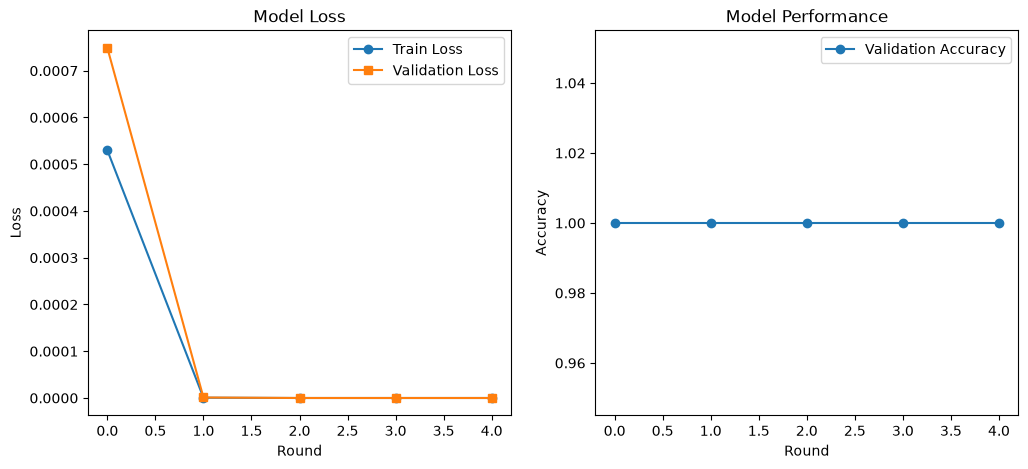

In [ ]:
# Plot the evaluation metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot train and validation loss
axes[0].plot([x['train_loss'] for x in train_performance], marker='o', label='Train Loss')
axes[0].plot([x['val_loss'] for x in eval_performance], marker='s', label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot Validation Accuracy
axes[1].plot([x['val_accuracy'] for x in eval_performance], marker='o', label='Validation Accuracy')
axes[1].set_title('Model Performance')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.show()